In [1]:
import numpy as np
import os, path
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
data_format = "decimal"
DATASET_FOLDER_PATH = os.path.join(os.getcwd(), r"dataset\decimal")



BENIGN_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_benign.csv")
DOS_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_DoS.csv")
SPOOFING_GAS_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_spoofing-GAS.csv")
SPOOFING_RPM_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_spoofing-RPM.csv")
SPOOFING_SPEED_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_spoofing-SPEED.csv")
SPOOFING_STEERING_WHEEL_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_spoofing-STEERING_WHEEL.csv")


assert os.path.isfile(BENIGN_DATASET_PATH) & \
    os.path.isfile(DOS_DATASET_PATH) & \
        os.path.isfile(SPOOFING_GAS_DATASET_PATH) & \
            os.path.isfile(SPOOFING_RPM_DATASET_PATH) & \
                os.path.isfile(SPOOFING_SPEED_DATASET_PATH) & \
                    os.path.isfile(SPOOFING_STEERING_WHEEL_DATASET_PATH)

In [3]:
benign_df = pd.read_csv(BENIGN_DATASET_PATH)
dos_df = pd.read_csv(DOS_DATASET_PATH)
spf_gas_df = pd.read_csv(SPOOFING_GAS_DATASET_PATH)
spf_rpm_df = pd.read_csv(SPOOFING_RPM_DATASET_PATH)
spf_speed_df = pd.read_csv(SPOOFING_SPEED_DATASET_PATH)
spf_str_wheel_df = pd.read_csv(SPOOFING_STEERING_WHEEL_DATASET_PATH)



print(f"Length of all benign is {len(benign_df)}")
print(f"Length of all dos is {len(dos_df)}")
print(f"Length of all spoof gas is {len(spf_gas_df)}")
print(f"Length of all spoof rpm is {len(spf_rpm_df)}")
print(f"Length of all spoof speed is {len(spf_speed_df)}")
print(f"Length of all spoof steering wheel is {len(spf_str_wheel_df)}")

Length of all benign is 1223737
Length of all dos is 74663
Length of all spoof gas is 9991
Length of all spoof rpm is 54900
Length of all spoof speed is 24951
Length of all spoof steering wheel is 19977


### Exploring the benign dataset

In [4]:
for col_idx, col in enumerate(benign_df.columns):
    print(f"\nUnique values in column {(col_idx, col)}: {benign_df.iloc[:, col_idx].unique()}")


print(f"Length of all benign is {len(benign_df)}")


Unique values in column (0, 'ID'): [  65 1068  535  131  936  359  369  516  609 1071 1085 1086  118  119
  125  531  532  534 1045 1200   71  357  512  514  560 1109  578 1438
  806  950  951  342  358  376  377  610 1057 1069 1072 1076 1077 1046
 1034 1409  938  939  132  862  909  952  995 1003 1084 1095  948  949
  817  967  947  963  986  994 1002  968  992 1125 1126 1127  942  753
  902 1081]

Unique values in column (1, 'DATA_0'): [ 96 132 127  15   1   0  16 192 125  20  62 255 100  28 158   8 186 122
   6 131  36  40  64 193 129  18  65 135  66  32  50  33  67  68 124  69
  70  71  72  73  74  75  76  77  78  79 133]

Unique values in column (2, 'DATA_1'): [  0  13 255 224 128 108   4  55  44  65 253  30 251 160  32 227 249   3
 247  96 245 243  34 241 239 192   1  17 136   2 112 252  76  16  80  84
  88  92 100 246 244 242 240 238 250 248 116 120 124 132 140]

Unique values in column (3, 'DATA_2'): [  0 160 127  39 125   9  16  66  15 247   8  52 128 169 130  32 246  56
 255

In [5]:
dedup_df = benign_df.drop_duplicates()

print(dedup_df)

print(f"Orignal df length {len(benign_df)}, after deduplication it is reduced to {len(dedup_df)}")

           ID  DATA_0  DATA_1  DATA_2  DATA_3  DATA_4  DATA_5  DATA_6  DATA_7  \
0          65      96       0       0       0       0       0       0       0   
1        1068     132      13     160       0       0       0       0       0   
2         535     127     255     127     255     127     255     127     255   
3         131      15     224       0       0       0       0       0       0   
4         936       1       0      39      16       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
1221651  1126       0     140     212     248      96      32      32       0   
1222301  1034     192       0       0       5      14      36      54       0   
1222470   132       0       0       0      76      31      47      12       0   
1222685   817     192       0     232      68      10       0       0       2   
1223114  1126       0     140     216     248      96      32      32       0   

          label category sp

### As you probably can notice, there are A LOT of duplicated entries.
### This can affect any ML or DL model as it might easily overfit on the most recurrent entries

Now let's see the distribution of those recurrent entries, as in real life some signals are more frequent than others

In [6]:
from sklearn.preprocessing import LabelEncoder
tmp_df = benign_df.copy()
tmp_df['concatted_row'] = np.nan

tmp_df['concatted_row'] = tmp_df.astype(str).agg('|'.join, axis=1)

tmp_df['concatted_row'] = LabelEncoder().fit_transform(tmp_df['concatted_row'])

print(tmp_df['concatted_row'])

0          2642
1           759
2          2637
3          1725
4          3516
           ... 
1223732    1677
1223733    1718
1223734    2619
1223735    2629
1223736    2636
Name: concatted_row, Length: 1223737, dtype: int64


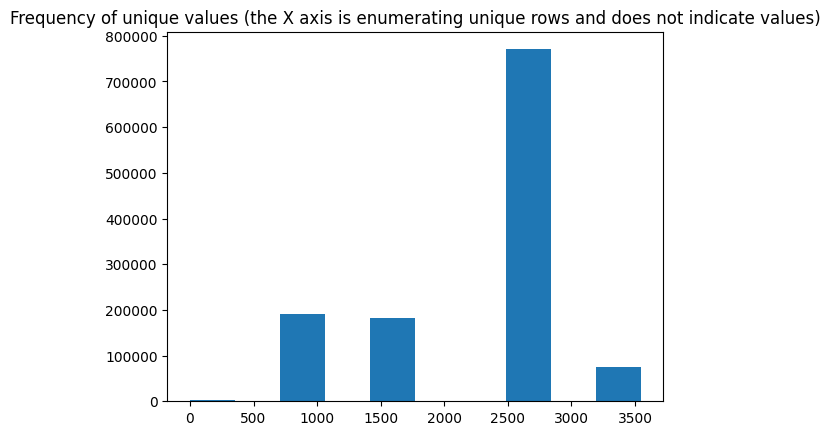

In [7]:
plt.hist(tmp_df['concatted_row'])
plt.title('Frequency of unique values (the X axis is enumerating unique rows and does not indicate values)')
plt.show()

### Seems like all the data in the benign set are nearly distributed uniformly, we can't do anything furthur

## I'll do the same analysis for all other classes

### Exploring the dos dataset

In [8]:
for col_idx, col in enumerate(dos_df.columns):
    print(f"\nUnique values in column {(col_idx, col)}: {dos_df.iloc[:, col_idx].unique()}")


print(f"Length of all dos is {len(dos_df)}")


Unique values in column (0, 'ID'): [291]

Unique values in column (1, 'DATA_0'): [ 0 14  1  3  9  5 13 11 10  2  8 15  7]

Unique values in column (2, 'DATA_1'): [ 0 11  5  1  8  7  6  2 15  4  3  9 10 14 13]

Unique values in column (3, 'DATA_2'): [ 0  4  9  6  3  7 10 13 11  2  1  8]

Unique values in column (4, 'DATA_3'): [ 0  4  7  5 10 14  1  6 11 12 13  9]

Unique values in column (5, 'DATA_4'): [ 0  3  8 14 11  7  6  5  9 13  4 10]

Unique values in column (6, 'DATA_5'): [ 0  3 11 10  1 15 13  7  9]

Unique values in column (7, 'DATA_6'): [ 0  8 15  2  7 10 14 12  1 11  5]

Unique values in column (8, 'DATA_7'): [ 0 12  4  5 15  8  9 11  7  3 14  2]

Unique values in column (9, 'label'): ['ATTACK']

Unique values in column (10, 'category'): ['DoS']

Unique values in column (11, 'specific_class'): ['DoS']
Length of all dos is 74663


In [9]:
dedup_df = dos_df.drop_duplicates()

print(dedup_df)

print(f"Orignal df length {len(dos_df)}, after deduplication it is reduced to {len(dedup_df)}")

        ID  DATA_0  DATA_1  DATA_2  DATA_3  DATA_4  DATA_5  DATA_6  DATA_7  \
0      291       0       0       0       0       0       0       0       0   
1      291      14      11       4       4       3       3       8      12   
2495   291       1       5       9       7       0      11      15       4   
4988   291       3       1       6       7       8      10       2       5   
7480   291       9       8       4       5       3       1       7      15   
9976   291       1       7       6      10      14      15      15       8   
12470  291       5       6       3       0       8      15       7       9   
14965  291      13       2       7      14      14       1      10      11   
17460  291      11      11      10       1      11      11       8       5   
19955  291      10      15      13       6       7      11      14       7   
22451  291       2       4      10      11      11       1       0       0   
24946  291       8       3      11       4       6       0      

### As you probably can notice, there are A LOT of duplicated entries.
### This can affect any ML or DL model as it might easily overfit on the most recurrent entries

Now let's see the distribution of those recurrent entries, as in real life some signals are more frequent than others

In [10]:
from sklearn.preprocessing import LabelEncoder
tmp_df = dos_df.copy()
tmp_df['concatted_row'] = np.nan

tmp_df['concatted_row'] = tmp_df.astype(str).agg('|'.join, axis=1)

tmp_df['concatted_row'] = LabelEncoder().fit_transform(tmp_df['concatted_row'])

print(tmp_df['concatted_row'])

0        0
1        5
2        5
3        5
4        5
        ..
74658    7
74659    7
74660    7
74661    7
74662    0
Name: concatted_row, Length: 74663, dtype: int64


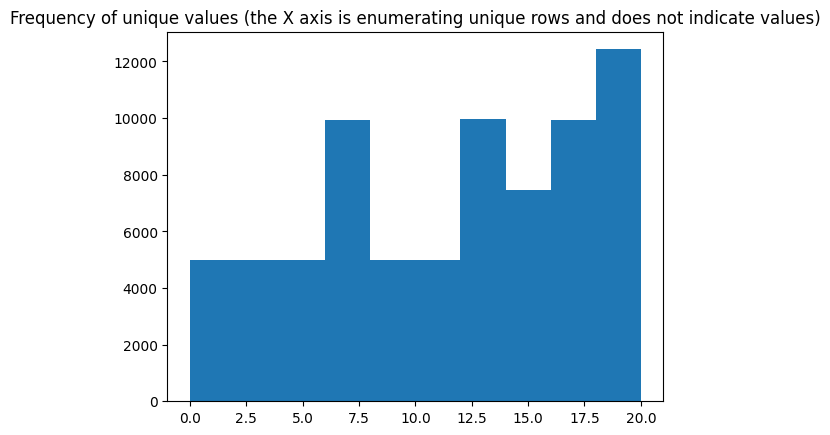

In [11]:
plt.hist(tmp_df['concatted_row'])
plt.title('Frequency of unique values (the X axis is enumerating unique rows and does not indicate values)')
plt.show()

### Exploring the Spoofing Gas dataset

In [12]:
for col_idx, col in enumerate(spf_gas_df.columns):
    print(f"\nUnique values in column {(col_idx, col)}: {spf_gas_df.iloc[:, col_idx].unique()}")


print(f"Length of all dos is {len(spf_gas_df)}")


Unique values in column (0, 'ID'): [513]

Unique values in column (1, 'DATA_0'): [0]

Unique values in column (2, 'DATA_1'): [0]

Unique values in column (3, 'DATA_2'): [0]

Unique values in column (4, 'DATA_3'): [0]

Unique values in column (5, 'DATA_4'): [0]

Unique values in column (6, 'DATA_5'): [0]

Unique values in column (7, 'DATA_6'): [ 0 64]

Unique values in column (8, 'DATA_7'): [125 156]

Unique values in column (9, 'label'): ['ATTACK']

Unique values in column (10, 'category'): ['SPOOFING']

Unique values in column (11, 'specific_class'): ['GAS']
Length of all dos is 9991


In [13]:
dedup_df = spf_gas_df.drop_duplicates()

print(dedup_df)

print(f"Orignal df length {len(spf_gas_df)}, after deduplication it is reduced to {len(dedup_df)}")

       ID  DATA_0  DATA_1  DATA_2  DATA_3  DATA_4  DATA_5  DATA_6  DATA_7  \
0     513       0       0       0       0       0       0       0     125   
4992  513       0       0       0       0       0       0      64     156   

       label  category specific_class  
0     ATTACK  SPOOFING            GAS  
4992  ATTACK  SPOOFING            GAS  
Orignal df length 9991, after deduplication it is reduced to 2


In [14]:
from sklearn.preprocessing import LabelEncoder
tmp_df = spf_gas_df.copy()
tmp_df['concatted_row'] = np.nan

tmp_df['concatted_row'] = tmp_df.astype(str).agg('|'.join, axis=1)

tmp_df['concatted_row'] = LabelEncoder().fit_transform(tmp_df['concatted_row'])

print(tmp_df['concatted_row'])

0       0
1       0
2       0
3       0
4       0
       ..
9986    1
9987    1
9988    1
9989    1
9990    1
Name: concatted_row, Length: 9991, dtype: int64


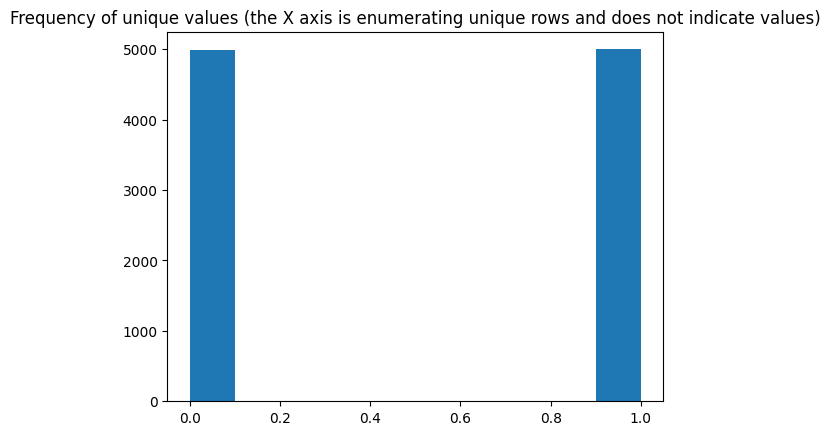

In [15]:
plt.hist(tmp_df['concatted_row'])
plt.title('Frequency of unique values (the X axis is enumerating unique rows and does not indicate values)')
plt.show()

### Exploring the Spoofing RPM dataset

In [16]:
for col_idx, col in enumerate(spf_rpm_df.columns):
    print(f"\nUnique values in column {(col_idx, col)}: {spf_rpm_df.iloc[:, col_idx].unique()}")


print(f"Length of all dos is {len(spf_rpm_df)}")


Unique values in column (0, 'ID'): [476 513]

Unique values in column (1, 'DATA_0'): [  2 160   0  64   6]

Unique values in column (2, 'DATA_1'): [61 53  7 15 23 30  0 31 28]

Unique values in column (3, 'DATA_2'): [ 23 221 177  60  84 245   3   0   2   6]

Unique values in column (4, 'DATA_3'): [ 19  69 239   3 221  37   0  35  63]

Unique values in column (5, 'DATA_4'): [  0 168  24   6]

Unique values in column (6, 'DATA_5'): [ 0 53  5 42]

Unique values in column (7, 'DATA_6'): [  0 148 138   2]

Unique values in column (8, 'DATA_7'): [ 0 34 41]

Unique values in column (9, 'label'): ['ATTACK']

Unique values in column (10, 'category'): ['SPOOFING']

Unique values in column (11, 'specific_class'): ['RPM']
Length of all dos is 54900


In [17]:
dedup_df = spf_rpm_df.drop_duplicates()

print(dedup_df)

print(f"Orignal df length {len(spf_rpm_df)}, after deduplication it is reduced to {len(dedup_df)}")

        ID  DATA_0  DATA_1  DATA_2  DATA_3  DATA_4  DATA_5  DATA_6  DATA_7  \
0      476       2      61      23      19       0       0       0       0   
4988   476       2      53     221      69       0       0       0       0   
9984   476       2       7     177     239       0       0       0       0   
14972  476       2      15      60       3       0       0       0       0   
19962  476       2      23      84     221       0       0       0       0   
24952  476       2      30     245       3       0       0       0       0   
34937  513     160      15       3      37     168      53     148      34   
39924  513       0       0       0       0       0       0       0       0   
44917  513      64      31       2      35      24       5     138      34   
49910  513       6      28       6      63       6      42       2      41   

        label  category specific_class  
0      ATTACK  SPOOFING            RPM  
4988   ATTACK  SPOOFING            RPM  
9984   ATTACK  SPO

In [18]:
from sklearn.preprocessing import LabelEncoder
tmp_df = spf_rpm_df.copy()
tmp_df['concatted_row'] = np.nan

tmp_df['concatted_row'] = tmp_df.astype(str).agg('|'.join, axis=1)

tmp_df['concatted_row'] = LabelEncoder().fit_transform(tmp_df['concatted_row'])

print(tmp_df['concatted_row'])

0        4
1        4
2        4
3        4
4        4
        ..
54895    9
54896    9
54897    9
54898    9
54899    6
Name: concatted_row, Length: 54900, dtype: int64


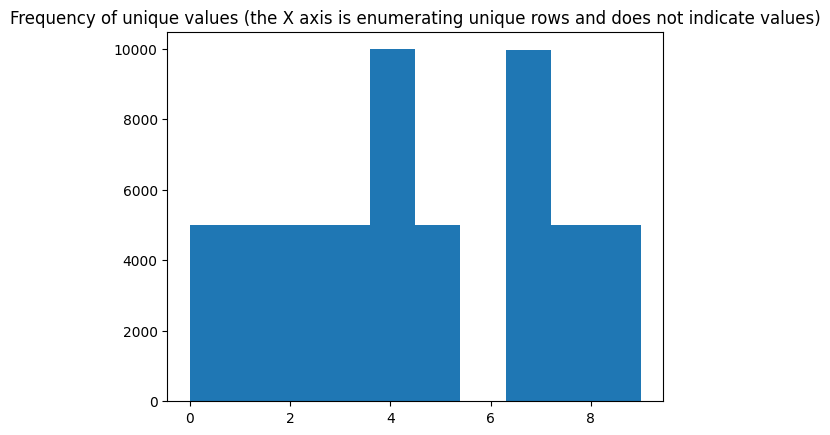

In [19]:
plt.hist(tmp_df['concatted_row'])
plt.title('Frequency of unique values (the X axis is enumerating unique rows and does not indicate values)')
plt.show()

### Exploring the Spoofing Speed dataset

In [20]:
for col_idx, col in enumerate(spf_speed_df.columns):
    print(f"\nUnique values in column {(col_idx, col)}: {spf_speed_df.iloc[:, col_idx].unique()}")


print(f"Length of all dos is {len(spf_speed_df)}")


Unique values in column (0, 'ID'): [344 513]

Unique values in column (1, 'DATA_0'): [6 0]

Unique values in column (2, 'DATA_1'): [12 16 20 28  0]

Unique values in column (3, 'DATA_2'): [6 0]

Unique values in column (4, 'DATA_3'): [51 54 57 63  0]

Unique values in column (5, 'DATA_4'): [  6 100]

Unique values in column (6, 'DATA_5'): [26 29 33 42  0]

Unique values in column (7, 'DATA_6'): [2]

Unique values in column (8, 'DATA_7'): [54 14 17 41  0]

Unique values in column (9, 'label'): ['ATTACK']

Unique values in column (10, 'category'): ['SPOOFING']

Unique values in column (11, 'specific_class'): ['SPEED']
Length of all dos is 24951


In [21]:
dedup_df = spf_speed_df.drop_duplicates()

print(dedup_df)

print(f"Orignal df length {len(spf_speed_df)}, after deduplication it is reduced to {len(dedup_df)}")

        ID  DATA_0  DATA_1  DATA_2  DATA_3  DATA_4  DATA_5  DATA_6  DATA_7  \
0      344       6      12       6      51       6      26       2      54   
4989   344       6      16       6      54       6      29       2      14   
9984   344       6      20       6      57       6      33       2      17   
14972  344       6      28       6      63       6      42       2      41   
19962  513       0       0       0       0     100       0       2       0   

        label  category specific_class  
0      ATTACK  SPOOFING          SPEED  
4989   ATTACK  SPOOFING          SPEED  
9984   ATTACK  SPOOFING          SPEED  
14972  ATTACK  SPOOFING          SPEED  
19962  ATTACK  SPOOFING          SPEED  
Orignal df length 24951, after deduplication it is reduced to 5


In [22]:
from sklearn.preprocessing import LabelEncoder
tmp_df = spf_speed_df.copy()
tmp_df['concatted_row'] = np.nan

tmp_df['concatted_row'] = tmp_df.astype(str).agg('|'.join, axis=1)

tmp_df['concatted_row'] = LabelEncoder().fit_transform(tmp_df['concatted_row'])

print(tmp_df['concatted_row'])

0        0
1        0
2        0
3        0
4        0
        ..
24946    4
24947    4
24948    4
24949    4
24950    4
Name: concatted_row, Length: 24951, dtype: int64


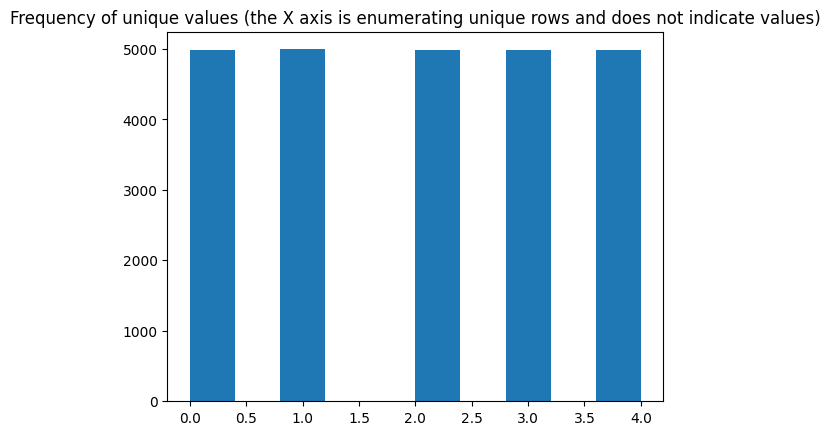

In [23]:
plt.hist(tmp_df['concatted_row'])
plt.title('Frequency of unique values (the X axis is enumerating unique rows and does not indicate values)')
plt.show()

### Exploring the Spoofing Steering Wheel dataset

In [24]:
for col_idx, col in enumerate(spf_str_wheel_df.columns):
    print(f"\nUnique values in column {(col_idx, col)}: {spf_str_wheel_df.iloc[:, col_idx].unique()}")


print(f"Length of all dos is {len(spf_str_wheel_df)}")


Unique values in column (0, 'ID'): [128]

Unique values in column (1, 'DATA_0'): [  0 132 194]

Unique values in column (2, 'DATA_1'): [0 3 1]

Unique values in column (3, 'DATA_2'): [0 2]

Unique values in column (4, 'DATA_3'): [ 0 35]

Unique values in column (5, 'DATA_4'): [ 0 24]

Unique values in column (6, 'DATA_5'): [0 5]

Unique values in column (7, 'DATA_6'): [  0 138]

Unique values in column (8, 'DATA_7'): [ 0 34]

Unique values in column (9, 'label'): ['ATTACK']

Unique values in column (10, 'category'): ['SPOOFING']

Unique values in column (11, 'specific_class'): ['STEERING_WHEEL']
Length of all dos is 19977


In [25]:
dedup_df = spf_str_wheel_df.drop_duplicates()

print(dedup_df)

print(f"Orignal df length {len(spf_str_wheel_df)}, after deduplication it is reduced to {len(dedup_df)}")

       ID  DATA_0  DATA_1  DATA_2  DATA_3  DATA_4  DATA_5  DATA_6  DATA_7  \
0     128       0       0       0       0       0       0       0       0   
1     128     132       3       2      35      24       5     138      34   
4996  128     194       1       2      35      24       5     138      34   

       label  category  specific_class  
0     ATTACK  SPOOFING  STEERING_WHEEL  
1     ATTACK  SPOOFING  STEERING_WHEEL  
4996  ATTACK  SPOOFING  STEERING_WHEEL  
Orignal df length 19977, after deduplication it is reduced to 3


In [26]:
from sklearn.preprocessing import LabelEncoder
tmp_df = spf_str_wheel_df.copy()
tmp_df['concatted_row'] = np.nan

tmp_df['concatted_row'] = tmp_df.astype(str).agg('|'.join, axis=1)

tmp_df['concatted_row'] = LabelEncoder().fit_transform(tmp_df['concatted_row'])

print(tmp_df['concatted_row'])

0        0
1        1
2        1
3        1
4        1
        ..
19972    1
19973    1
19974    1
19975    1
19976    0
Name: concatted_row, Length: 19977, dtype: int64


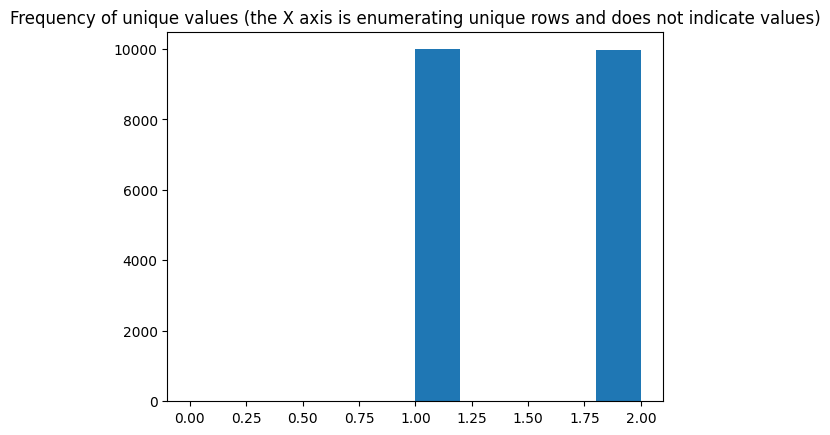

In [27]:
plt.hist(tmp_df['concatted_row'])
plt.title('Frequency of unique values (the X axis is enumerating unique rows and does not indicate values)')
plt.show()